# Cross-Validation of Subjective and Objective Fatigue Measures

This notebook validates EEG-based objective fatigue indicators against the Karolinska Sleepiness Scale (KSS) subjective ratings.

**Objective indicators** (per block of 10 stimuli):
- Occipital relative alpha power (8–13 Hz), computed via Welch PSD
- Blink rate (blinks/min), detected from Fp1 EOG channel

**Subjective indicator**: KSS ratings at T1–T6 (after each block of 10 stimuli)

**Statistical methods**:
- Repeated-measures correlation (rm_corr)
- Pearson / Spearman correlation
- Linear mixed-effects models (LMM) with random intercept per subject

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import mne
from mne_bids import BIDSPath, read_raw_bids
from scipy.signal import find_peaks
from scipy.integrate import trapezoid
from scipy.stats import pearsonr, spearmanr
import pingouin as pg
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['savefig.dpi'] = 500
plt.rcParams['figure.dpi'] = 500
plt.rcParams['font.family'] = 'Times New Roman'

## 2. Configuration

In [2]:
# Data paths -- modify to match your local setup
BIDS_ROOT = r'D:\Files\EEG实验数据\0ssvep_dataset\derivatives\preprocessed'
KSS_PATH = r'D:\Files\EEG实验数据\0ssvep_dataset\phenotype\sub_kss_timeseries.tsv'

TASK = 'ssvep'
DATATYPE = 'eeg'
SUFFIX = 'eeg'

TRIALS_PER_BLOCK = 10
N_BLOCKS = 6

# Occipital and EOG channel selection
OCCIPITAL_CHS = ['PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Pz', 'P3', 'P4']
EOG_CH = 'Fp1'

# PSD and blink detection parameters
ALPHA_LOW = 8.0
ALPHA_HIGH = 13.0
PSD_FMIN = 1.0
PSD_FMAX = 40.0
EOG_LOW = 1.0
EOG_HIGH = 10.0
BLINK_HEIGHT_UV = 50.0
BLINK_MIN_DIST_S = 0.2

## 3. Load KSS Data

Reshape KSS from wide to long format. T0 (pre-experiment baseline) is excluded; T1–T6 correspond to Blocks 1–6.

In [3]:
def discover_subjects(bids_root):
    subjects = []
    for entry in sorted(os.listdir(bids_root)):
        if entry.startswith('sub-') and os.path.isdir(os.path.join(bids_root, entry)):
            eeg_dir = os.path.join(bids_root, entry, 'eeg')
            if os.path.isdir(eeg_dir):
                subjects.append(entry.replace('sub-', ''))
    return subjects


all_subjects = discover_subjects(BIDS_ROOT)
print(f'Found {len(all_subjects)} subjects: {all_subjects}')

df_kss = pd.read_csv(KSS_PATH, sep='\t')
print(f'KSS data: {len(df_kss)} subjects, timepoints: {[c for c in df_kss.columns if c.startswith("T")]}')

# Reshape to long format (T1-T6 only)
kss_melted = df_kss.melt(
    id_vars='participant_id',
    value_vars=[f'T{i}' for i in range(1, N_BLOCKS + 1)],
    var_name='Timepoint',
    value_name='KSS_Score',
)
kss_melted['Block_Num'] = kss_melted['Timepoint'].str.replace('T', '').astype(int)
kss_melted['Subject'] = kss_melted['participant_id'].str.replace('sub-', '')
kss_melted = kss_melted.drop(columns=['participant_id', 'Timepoint'])

print(f'KSS long format: {len(kss_melted)} rows ({len(all_subjects)} subjects x {N_BLOCKS} blocks)')

Found 30 subjects: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30']
KSS data: 30 subjects, timepoints: ['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6']
KSS long format: 180 rows (30 subjects x 6 blocks)


## 4. EEG Feature Extraction

For each block (10 consecutive stimuli), extract:
1. **Occipital relative alpha power** — ratio of alpha band (8–13 Hz) power to total band (1–40 Hz) power, averaged across occipital channels
2. **Blink rate** — blinks per minute, detected via bandpass filtering and peak detection on Fp1

In [4]:
def extract_relative_alpha(raw, sfreq, eeg_picks):
    """Compute occipital relative alpha power via Welch PSD."""
    psd_obj = raw.compute_psd(
        method='welch', fmin=PSD_FMIN, fmax=PSD_FMAX,
        picks=eeg_picks, n_fft=int(sfreq * 2), verbose=False,
    )
    psds, freqs = psd_obj.get_data(return_freqs=True)
    mean_psd = psds.mean(axis=0)

    alpha_mask = (freqs >= ALPHA_LOW) & (freqs <= ALPHA_HIGH)
    total_mask = (freqs >= PSD_FMIN) & (freqs <= PSD_FMAX)

    alpha_power = trapezoid(mean_psd[alpha_mask], freqs[alpha_mask])
    total_power = trapezoid(mean_psd[total_mask], freqs[total_mask])

    return alpha_power / total_power if total_power > 0 else np.nan


def extract_blink_rate(raw, sfreq, eog_pick):
    """Compute blink rate (blinks/min) from EOG channel."""
    available = [ch for ch in [eog_pick] if ch in raw.ch_names]
    if not available:
        return np.nan

    raw_eog = raw.copy().filter(l_freq=EOG_LOW, h_freq=EOG_HIGH, picks=available, verbose=False)
    eog_data = raw_eog.get_data(picks=available)[0]

    height_v = BLINK_HEIGHT_UV * 1e-6
    min_dist_samples = int(BLINK_MIN_DIST_S * sfreq)
    peaks, _ = find_peaks(np.abs(eog_data), height=height_v, distance=min_dist_samples)

    duration_s = len(eog_data) / sfreq
    return len(peaks) / duration_s * 60 if duration_s > 0 else np.nan

In [5]:
def process_subject(subject_id):
    """Extract block-level objective features for a single subject."""
    rows = []
    try:
        bids_path = BIDSPath(
            subject=subject_id, task=TASK, suffix=SUFFIX,
            datatype=DATATYPE, root=BIDS_ROOT,
        )
        raw = read_raw_bids(bids_path=bids_path, verbose=False)
        raw.load_data()
        sfreq = raw.info['sfreq']

        # Set auxiliary channel types
        aux_types = {
            'REOG': 'eog', 'LEOG': 'eog',
            'EMG1': 'emg', 'EMG2': 'emg', 'EMG3': 'emg', 'EMG4': 'emg', 'EMG5': 'emg',
            'EMG6': 'emg', 'EMG7': 'emg', 'EMG8': 'emg', 'EMG9': 'emg',
            'SpO2': 'misc', 'PulseRate': 'misc', 'Pleth': 'misc',
        }
        present = {ch: ct for ch, ct in aux_types.items() if ch in raw.ch_names}
        if present:
            try:
                raw.set_channel_types(present, on_unit_change='ignore')
            except TypeError:
                raw.set_channel_types(present)

        all_events, all_event_dict = mne.events_from_annotations(raw, verbose=False)
        stim_events = {name: code for name, code in all_event_dict.items() if name.startswith('stim_')}

        if not stim_events:
            print(f'  sub-{subject_id}: no stim events, skipping')
            return rows

        stim_mask = np.isin(all_events[:, 2], list(stim_events.values()))
        stim_onsets = all_events[stim_mask, 0]
        n_stim = len(stim_onsets)
        n_blocks = min(N_BLOCKS, n_stim // TRIALS_PER_BLOCK)

        for block_idx in range(n_blocks):
            start_sample = stim_onsets[block_idx * TRIALS_PER_BLOCK]
            tmin = start_sample / sfreq

            if (block_idx + 1) * TRIALS_PER_BLOCK < n_stim:
                end_sample = stim_onsets[(block_idx + 1) * TRIALS_PER_BLOCK]
                raw_block = raw.copy().crop(tmin=tmin, tmax=end_sample / sfreq)
            else:
                raw_block = raw.copy().crop(tmin=tmin)

            avail_occ = [ch for ch in OCCIPITAL_CHS if ch in raw_block.ch_names]
            rel_alpha = extract_relative_alpha(raw_block, sfreq, avail_occ) if avail_occ else np.nan
            blink_rate = extract_blink_rate(raw_block, sfreq, EOG_CH)

            rows.append({
                'Subject': subject_id,
                'Block_Num': block_idx + 1,
                'Relative_Alpha': rel_alpha,
                'Blink_Rate': blink_rate,
            })

    except Exception as e:
        print(f'  sub-{subject_id} error: {e}')

    return rows

## 5. Batch Processing & Data Merge

In [6]:
all_rows = []
for subj in all_subjects:
    print(f'Processing sub-{subj} ...', end=' ')
    rows = process_subject(subj)
    all_rows.extend(rows)
    print(f'{len(rows)} blocks')

df_eeg = pd.DataFrame(all_rows)
print(f'\nEEG feature extraction complete: {len(df_eeg)} rows ({df_eeg["Subject"].nunique()} subjects)')

# Merge EEG features with KSS ratings
df_merged = pd.merge(
    df_eeg, kss_melted,
    on=['Subject', 'Block_Num'],
    how='inner',
)
df_merged = df_merged.dropna(subset=['Relative_Alpha', 'Blink_Rate', 'KSS_Score'])

print(f'Merged data: {len(df_merged)} rows, {df_merged["Subject"].nunique()} subjects')
print(f'KSS distribution: mean={df_merged["KSS_Score"].mean():.2f}, SD={df_merged["KSS_Score"].std():.2f}, '
      f'range=[{df_merged["KSS_Score"].min()}, {df_merged["KSS_Score"].max()}]')

Processing sub-01 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-02 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-03 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-04 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-05 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-06 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-07 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-08 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-09 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-10 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-11 ... Reading 0 ... 405000  =      0.000 ...  1620.000 secs...
6 blocks
Processing sub-12 ... Reading 0 

## 6. Descriptive Statistics

In [7]:
block_desc = df_merged.groupby('Block_Num').agg(
    N=('Subject', 'count'),
    KSS_Mean=('KSS_Score', 'mean'),
    KSS_SD=('KSS_Score', 'std'),
    Alpha_Mean=('Relative_Alpha', 'mean'),
    Alpha_SD=('Relative_Alpha', 'std'),
    Blink_Mean=('Blink_Rate', 'mean'),
    Blink_SD=('Blink_Rate', 'std'),
).round(3)

display(block_desc)

for var in ['KSS_Score', 'Relative_Alpha', 'Blink_Rate']:
    trend = df_merged.groupby('Block_Num')[var].mean()
    print(f'{var}: Block1={trend.iloc[0]:.3f} -> Block6={trend.iloc[-1]:.3f} (delta={trend.iloc[-1]-trend.iloc[0]:+.3f})')

,N,KSS_Mean,KSS_SD,Alpha_Mean,Alpha_SD,Blink_Mean,Blink_SD
Block_Num,,,,,,,
1,30,1.700,0.837,0.077,0.055,33.057,15.226
2,30,1.967,0.890,0.078,0.048,34.837,15.012
3,30,2.233,0.898,0.074,0.051,35.152,16.910
4,30,2.467,1.042,0.074,0.056,35.114,17.719
5,30,2.733,1.202,0.086,0.065,31.961,18.075
6,30,2.800,1.243,0.115,0.087,26.725,16.193


KSS_Score: Block1=1.700 -> Block6=2.800 (delta=+1.100)
Relative_Alpha: Block1=0.077 -> Block6=0.115 (delta=+0.039)
Blink_Rate: Block1=33.057 -> Block6=26.725 (delta=-6.331)


## 7. Correlation Analysis

### 7.1 Repeated-measures correlation (rm_corr)

Controls for inter-subject variability by computing a common within-subject correlation (Bakdash & Marusich, 2017).

In [8]:
print('=== Relative Alpha Power vs KSS (rm_corr) ===')
rc_alpha = pg.rm_corr(data=df_merged, x='Relative_Alpha', y='KSS_Score', subject='Subject')
display(rc_alpha)

print('\n=== Blink Rate vs KSS (rm_corr) ===')
rc_blink = pg.rm_corr(data=df_merged, x='Blink_Rate', y='KSS_Score', subject='Subject')
display(rc_blink)

=== Relative Alpha Power vs KSS (rm_corr) ===


,r,dof,pval,CI95,power
rm_corr,0.153976,149,0.059075,"[-0.01, 0.31]",0.473583



=== Blink Rate vs KSS (rm_corr) ===


,r,dof,pval,CI95,power
rm_corr,-0.178398,149,0.02841,"[-0.33, -0.02]",0.594905


### 7.2 Pearson / Spearman correlation

In [9]:
for var in ['Relative_Alpha', 'Blink_Rate']:
    r_p, p_p = pearsonr(df_merged[var], df_merged['KSS_Score'])
    r_s, p_s = spearmanr(df_merged[var], df_merged['KSS_Score'])
    print(f'{var} vs KSS:  Pearson r={r_p:.4f}, p={p_p:.4e}  |  Spearman rho={r_s:.4f}, p={p_s:.4e}')

Relative_Alpha vs KSS:  Pearson r=-0.0418, p=5.7772e-01  |  Spearman rho=-0.0314, p=6.7573e-01
Blink_Rate vs KSS:  Pearson r=-0.1834, p=1.3732e-02  |  Spearman rho=-0.1780, p=1.6823e-02


### 7.3 Linear mixed-effects models (LMM)

Random intercept per subject (REML estimation). Three models are fitted:
- `KSS ~ Relative_Alpha`
- `KSS ~ Blink_Rate`
- `KSS ~ Relative_Alpha + Blink_Rate`

In [10]:
model_alpha = smf.mixedlm('KSS_Score ~ Relative_Alpha', df_merged, groups=df_merged['Subject'])
result_alpha = model_alpha.fit()
print('=== LMM: KSS ~ Relative_Alpha ===')
print(result_alpha.summary())

model_blink = smf.mixedlm('KSS_Score ~ Blink_Rate', df_merged, groups=df_merged['Subject'])
result_blink = model_blink.fit()
print('\n=== LMM: KSS ~ Blink_Rate ===')
print(result_blink.summary())

model_both = smf.mixedlm('KSS_Score ~ Relative_Alpha + Blink_Rate', df_merged, groups=df_merged['Subject'])
result_both = model_both.fit()
print('\n=== LMM: KSS ~ Relative_Alpha + Blink_Rate ===')
print(result_both.summary())

=== LMM: KSS ~ Relative_Alpha ===
         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: KSS_Score
No. Observations:  180     Method:             REML     
No. Groups:        30      Scale:              0.5129   
Min. group size:   6       Log-Likelihood:     -227.8002
Max. group size:   6       Converged:          Yes      
Mean group size:   6.0                                  
--------------------------------------------------------
               Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      2.157    0.201 10.720 0.000  1.763  2.551
Relative_Alpha 1.901    1.373  1.384 0.166 -0.791  4.592
Group Var      0.729    0.331                           


=== LMM: KSS ~ Blink_Rate ===
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: KSS_Score
No. Observations: 180     Method:             REML     
No. Groups:       30      Scale:            

## 8. Visualization

### 8.1 Block-level trends

Mean ± SEM across subjects for each block.

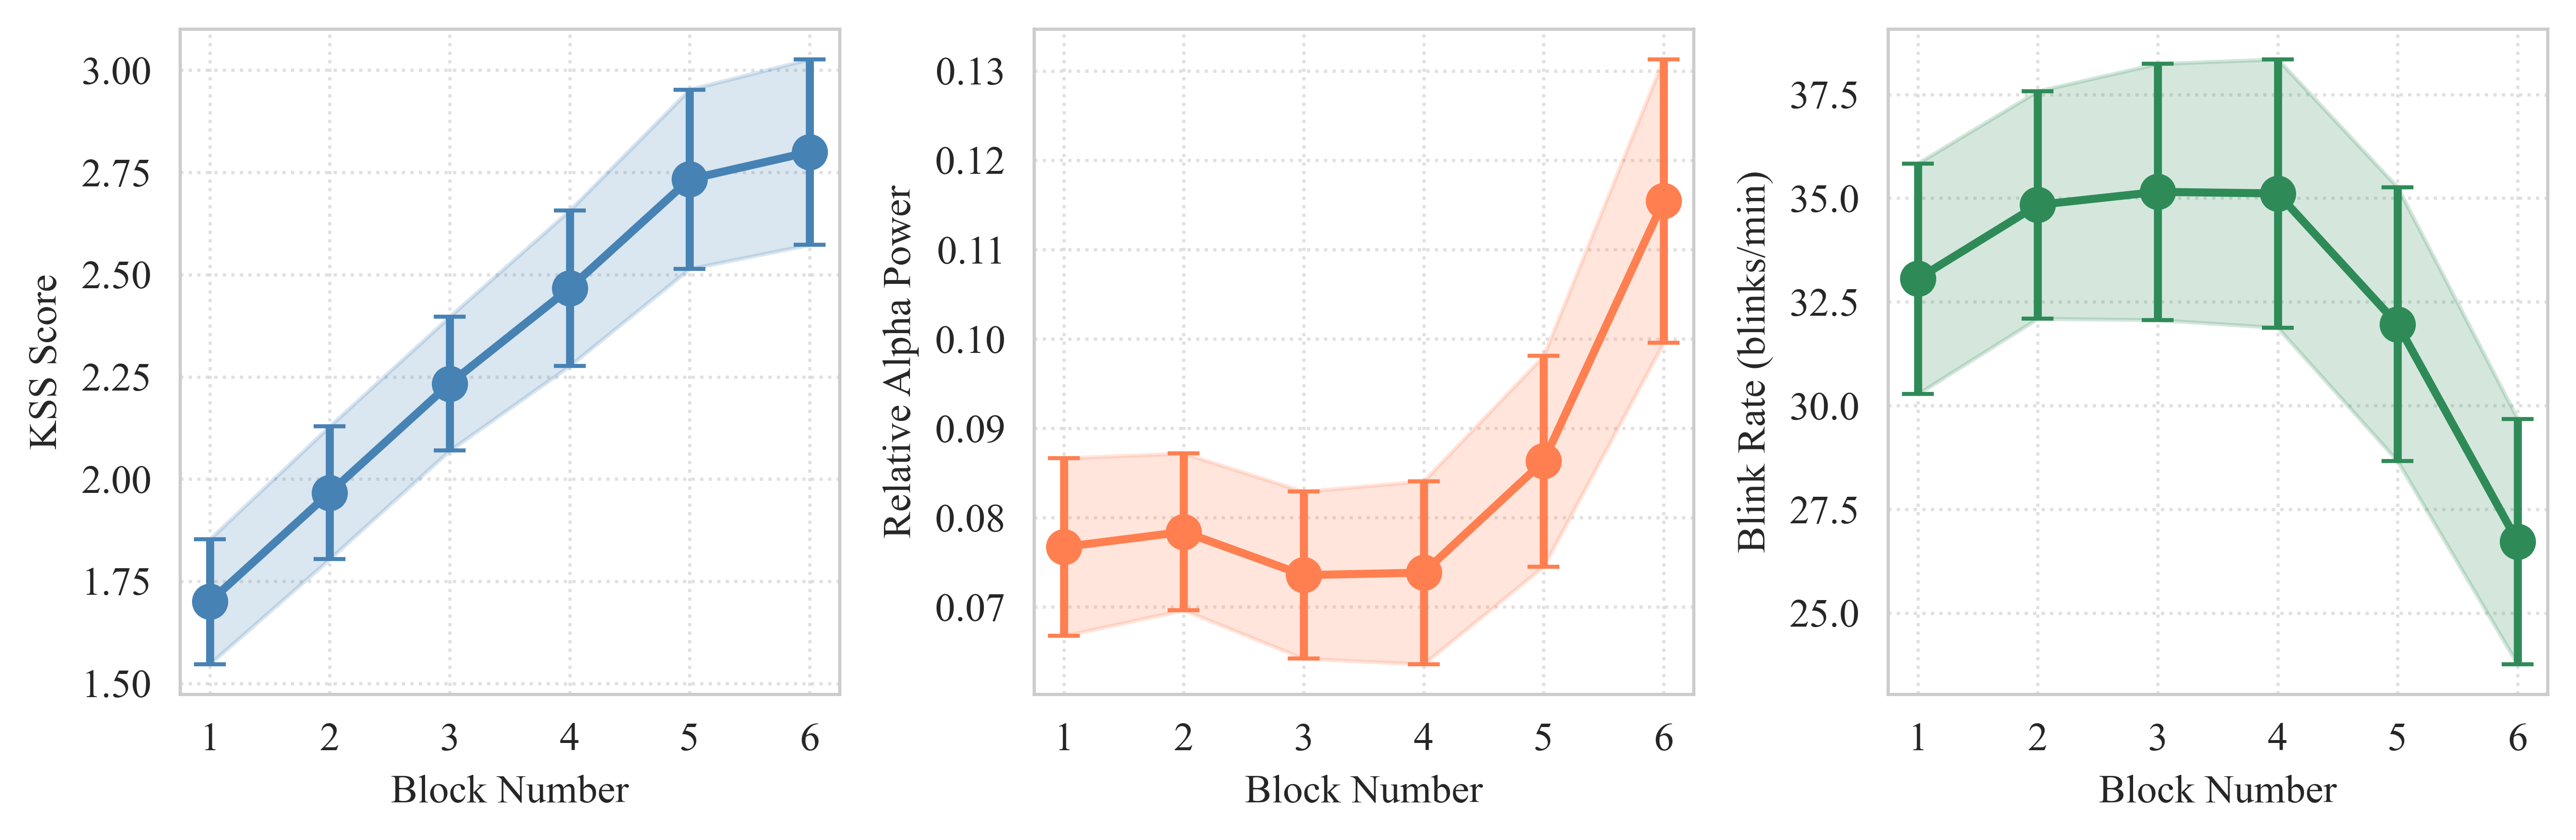

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=600)

for ax, var, label, color in zip(
    axes,
    ['KSS_Score', 'Relative_Alpha', 'Blink_Rate'],
    ['KSS Score', 'Relative Alpha Power', 'Blink Rate (blinks/min)'],
    ['steelblue', 'coral', 'seagreen'],
):
    block_means = df_merged.groupby('Block_Num')[var].agg(['mean', 'std', 'count'])
    block_means['sem'] = block_means['std'] / np.sqrt(block_means['count'])

    ax.errorbar(block_means.index, block_means['mean'], yerr=block_means['sem'],
                fmt='o-', color=color, linewidth=2, markersize=8, capsize=4)
    ax.fill_between(block_means.index,
                    block_means['mean'] - block_means['sem'],
                    block_means['mean'] + block_means['sem'],
                    alpha=0.2, color=color)
    ax.set_xlabel('Block Number')
    ax.set_ylabel(label)
    ax.set_xticks(range(1, N_BLOCKS + 1))
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 8.2 rm_corr scatter plots

Each subject's data points are color-coded. The black line shows the rm_corr fixed-effect fit; the gray band is the bootstrap 95% CI.

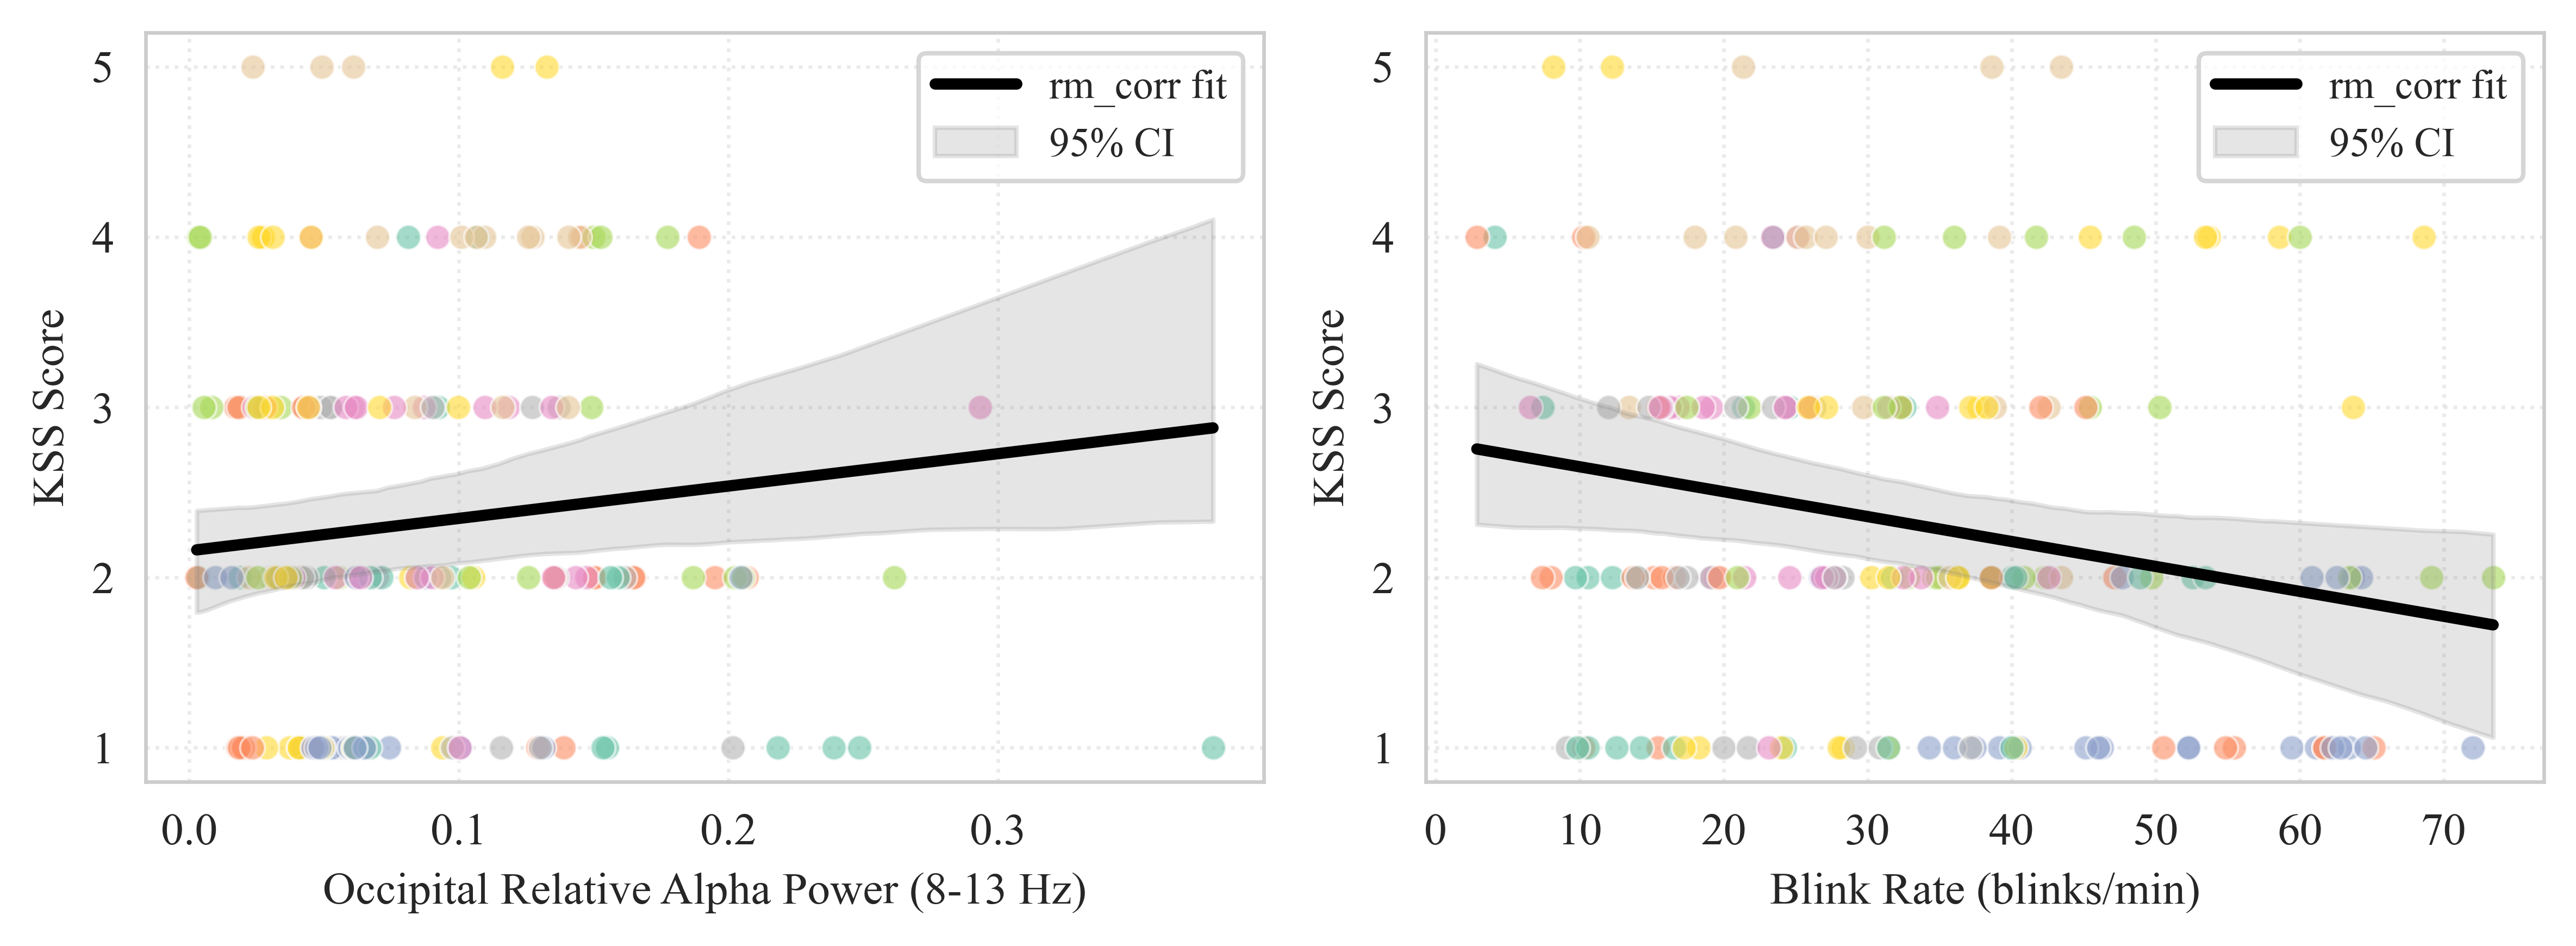

In [12]:
def plot_rm_corr_line(data, x_var, y_var, subject_var, x_label, y_label, ax):
    """Plot rm_corr scatter with fixed-effect fit line and 95% CI."""
    subjects = data[subject_var].unique()
    palette = sns.color_palette('Set2', len(subjects))
    for i, sub in enumerate(subjects):
        sub_data = data[data[subject_var] == sub]
        ax.scatter(sub_data[x_var], sub_data[y_var], color=palette[i], alpha=0.6, s=30,
                   edgecolors='white', linewidth=0.5)

    model = smf.mixedlm(f'{y_var} ~ {x_var}', data, groups=data[subject_var])
    result = model.fit()
    slope = result.params[x_var]
    intercept = result.params['Intercept']

    x_range = np.linspace(data[x_var].min(), data[x_var].max(), 200)
    y_fit = intercept + slope * x_range

    # Bootstrap 95% CI
    n_boot = 500
    y_boot = np.zeros((n_boot, len(x_range)))
    for b in range(n_boot):
        sampled_subs = np.random.choice(subjects, size=len(subjects), replace=True)
        boot_data = pd.concat([data[data[subject_var] == s] for s in sampled_subs], ignore_index=True)
        try:
            m = smf.mixedlm(f'{y_var} ~ {x_var}', boot_data, groups=boot_data[subject_var])
            r = m.fit()
            y_boot[b] = r.params['Intercept'] + r.params[x_var] * x_range
        except Exception:
            y_boot[b] = np.nan

    ci_low = np.nanpercentile(y_boot, 2.5, axis=0)
    ci_high = np.nanpercentile(y_boot, 97.5, axis=0)

    ax.plot(x_range, y_fit, color='black', linewidth=2.5, label='rm_corr fit')
    ax.fill_between(x_range, ci_low, ci_high, color='gray', alpha=0.2, label='95% CI')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='best', fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

plot_rm_corr_line(df_merged, 'Relative_Alpha', 'KSS_Score', 'Subject',
                  'Occipital Relative Alpha Power (8-13 Hz)', 'KSS Score', axes[0])

plot_rm_corr_line(df_merged, 'Blink_Rate', 'KSS_Score', 'Subject',
                  'Blink Rate (blinks/min)', 'KSS Score', axes[1])

plt.tight_layout()
plt.show()

### 8.3 Within-subject regression slopes

Individual OLS regression slopes of each objective indicator against KSS, showing inter-subject variability in the direction and magnitude of the relationship.

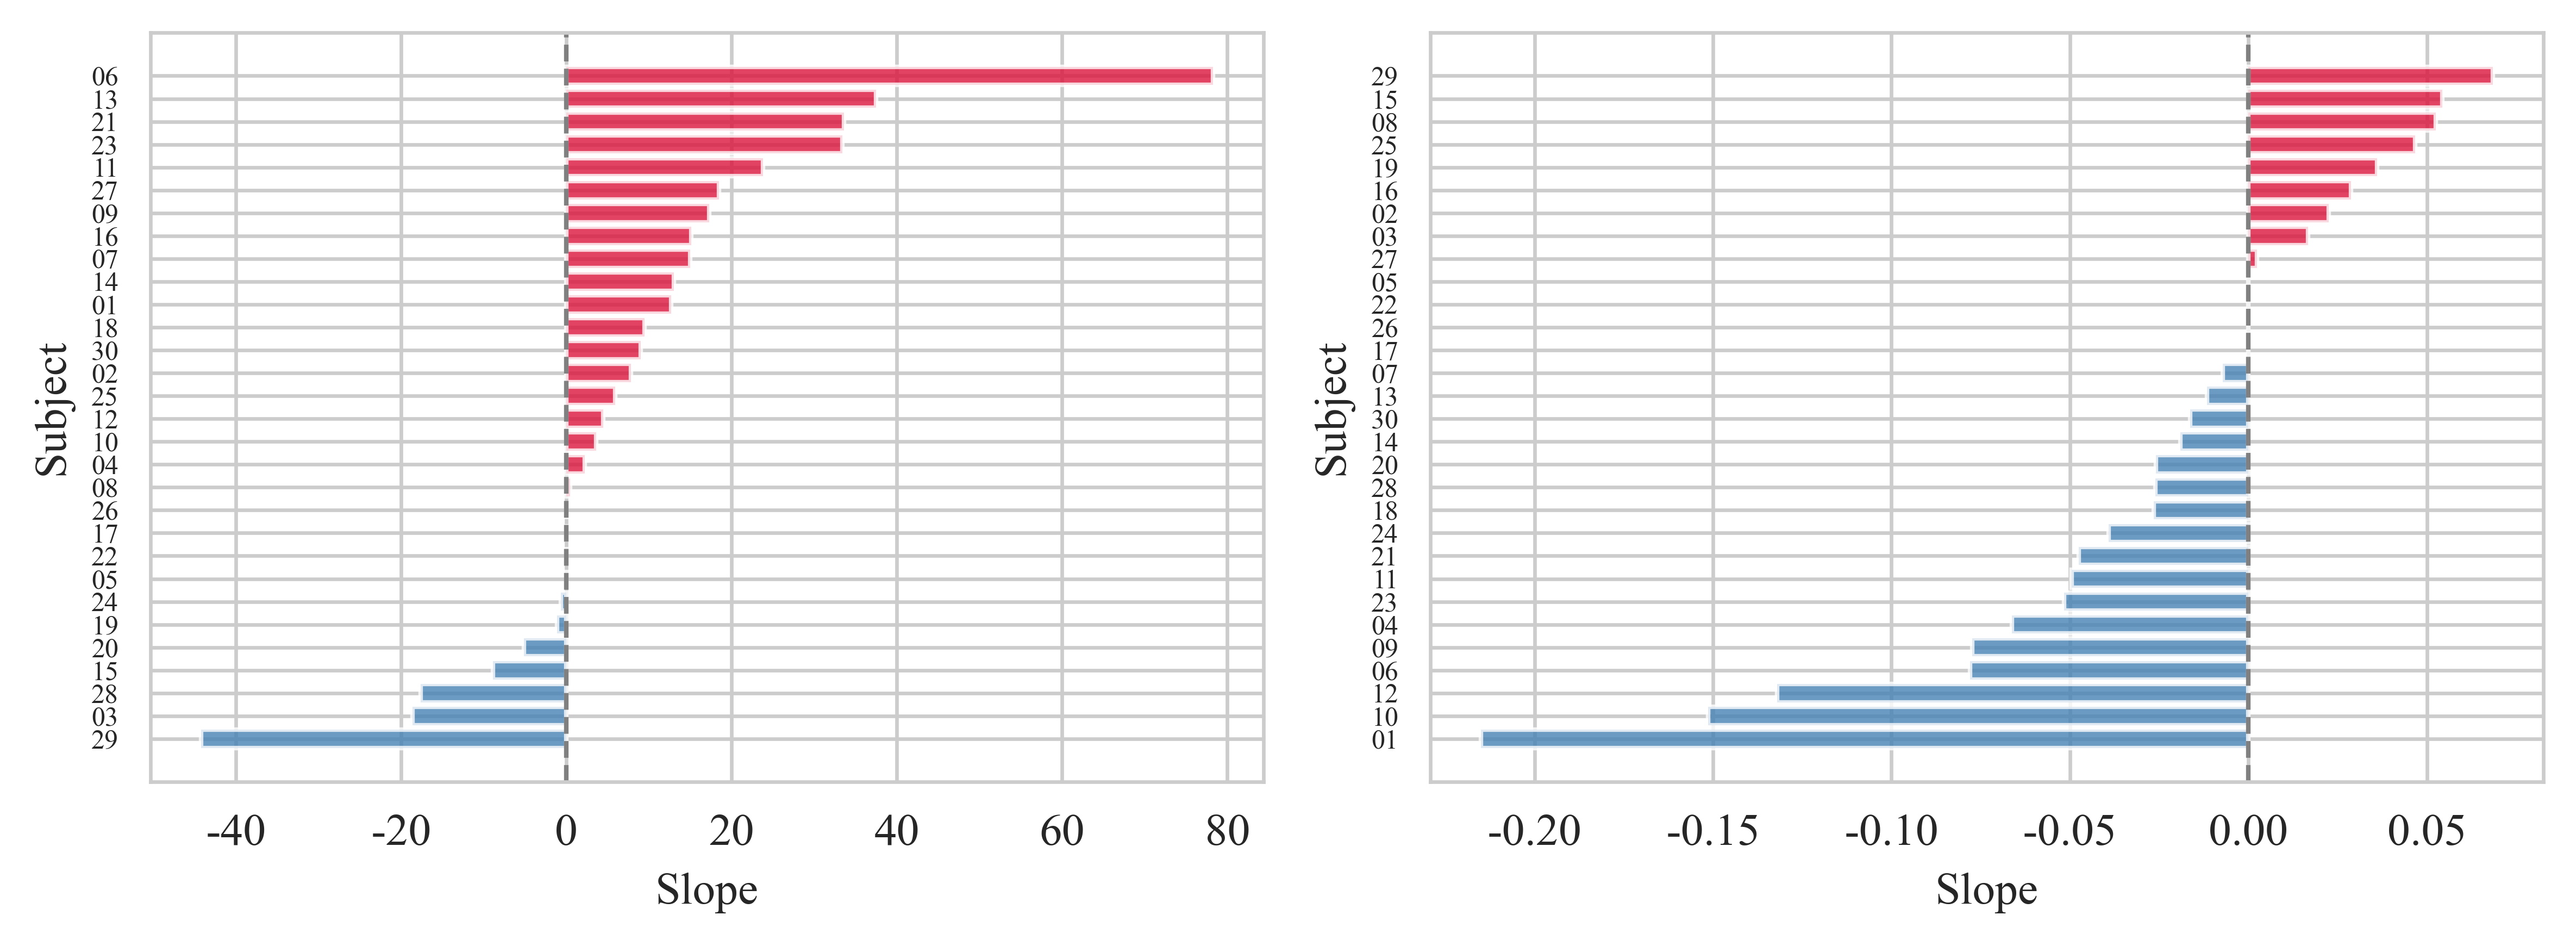

,Slope_Alpha_KSS,Slope_Blink_KSS
count,30.000,30.000
mean,8.159,-0.024
std,21.003,0.063
min,-44.220,-0.215
25%,-0.000,-0.049
50%,5.196,-0.014
75%,15.071,0.013
max,78.253,0.068


In [13]:
subj_slopes = []
for sub in df_merged['Subject'].unique():
    sub_data = df_merged[df_merged['Subject'] == sub]
    if len(sub_data) < 3:
        continue
    slope_alpha = np.polyfit(sub_data['Relative_Alpha'], sub_data['KSS_Score'], 1)[0]
    slope_blink = np.polyfit(sub_data['Blink_Rate'], sub_data['KSS_Score'], 1)[0]
    subj_slopes.append({
        'Subject': sub,
        'Slope_Alpha_KSS': slope_alpha,
        'Slope_Blink_KSS': slope_blink,
    })

df_slopes = pd.DataFrame(subj_slopes)

fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=600)

for ax, slope_col, label in zip(
    axes,
    ['Slope_Alpha_KSS', 'Slope_Blink_KSS'],
    ['Alpha -> KSS Slope', 'Blink Rate -> KSS Slope'],
):
    df_slopes_sorted = df_slopes.sort_values(slope_col)
    colors = ['crimson' if v > 0 else 'steelblue' for v in df_slopes_sorted[slope_col]]
    ax.barh(df_slopes_sorted['Subject'], df_slopes_sorted[slope_col], color=colors, alpha=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Slope')
    ax.set_ylabel('Subject')
    ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.show()

display(df_slopes.describe().round(3))

## 9. Summary of Results

In [14]:
def get_p(row_dict):
    for key in ['p-val', 'pval', 'p', 'p_uncorrected']:
        if key in row_dict:
            return float(row_dict[key])
    raise KeyError(f'No p-value column found. Available: {list(row_dict.keys())}')

def get_r(row_dict):
    for key in ['r', 'corr']:
        if key in row_dict:
            return float(row_dict[key])
    raise KeyError(f'No r column found. Available: {list(row_dict.keys())}')

r_alpha_val, p_alpha_val = get_r(rc_alpha.iloc[0].to_dict()), get_p(rc_alpha.iloc[0].to_dict())
r_blink_val, p_blink_val = get_r(rc_blink.iloc[0].to_dict()), get_p(rc_blink.iloc[0].to_dict())

summary_rows = [
    {'Method': 'rm_corr (Alpha vs KSS)', 'r': r_alpha_val, 'p': p_alpha_val},
    {'Method': 'rm_corr (Blink vs KSS)', 'r': r_blink_val, 'p': p_blink_val},
]

df_summary = pd.DataFrame(summary_rows)
df_summary['Sig'] = df_summary['p'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
df_summary = df_summary.round(4)

display(df_summary)

print(f'LMM Alpha fixed effect: beta={result_alpha.params["Relative_Alpha"]:.4f}, '
      f'p={result_alpha.pvalues["Relative_Alpha"]:.4e}')
print(f'LMM Blink fixed effect: beta={result_blink.params["Blink_Rate"]:.4f}, '
      f'p={result_blink.pvalues["Blink_Rate"]:.4e}')

,Method,r,p,Sig
0,rm_corr (Alpha vs KSS),0.1540,0.0591,ns
1,rm_corr (Blink vs KSS),-0.1784,0.0284,*


LMM Alpha fixed effect: beta=1.9009, p=1.6630e-01
LMM Blink fixed effect: beta=-0.0146, p=1.6066e-02


## 10. Save Results

In [15]:
output_dir = os.path.join(os.path.dirname(BIDS_ROOT), 'fatigue_cross_validation_results')
os.makedirs(output_dir, exist_ok=True)

df_merged.to_csv(os.path.join(output_dir, 'merged_features_kss.csv'), index=False)
df_summary.to_csv(os.path.join(output_dir, 'correlation_summary.csv'), index=False)
block_desc.to_csv(os.path.join(output_dir, 'block_descriptive_stats.csv'))

print(f'Results saved to: {output_dir}')

Results saved to: D:\Files\EEG实验数据\0ssvep_dataset\derivatives\fatigue_cross_validation_results
